In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import json


# 1. Carga de datos

In [2]:
# Cargamos los datos
df = pd.read_csv("dataset/datos_finales.csv") # Datos scrapeados

# Cargamos los datos relacionados con las tasas de empleo y paro
df_paro = pd.read_csv(
    "dataset/datos_paro_actividad_ine.csv",
    sep=";",
    encoding="cp1252"
) # https://www.ine.es/jaxiT3/Tabla.htm?t=65349

# Importamos los mapeos de provincias del INE para nuestro dataset original
with open("dataset/provincia_mapping.json", "r", encoding="utf-8") as f:
    prov_map = json.load(f)

# Cargamos los datos de rentas netas medias por persona y hogar por cada provincia
df_rentas = pd.read_csv(
    "dataset/datos_rentas_ine.csv",
    sep=";",
    encoding="cp1252"
) # https://www.ine.es/jaxiT3/files/t/csv_bdsc

# Cargamos los datos del turimos
df_turism = pd.read_csv(
    "dataset/datos_turismo_ine.csv",
    sep=";",
    encoding="utf-8"
)

df_empresas= pd.read_csv(
    "dataset/datos_num_empresas_ine.csv",
    sep=";",
    encoding="cp1252"
)


# 2. Data cleaning
## 2.1 Datos tasa de paro y actividad economica

In [3]:
# Nos quedamos con el periodo mas reciente y el datos de hombres y mujeres combinado
df_paro[(df_paro['Periodo'] =='2026T1') & (df_paro['Sexo']=='Ambos sexos')]

# Limpiamos el indice provincias de la numeracion del INE
df_paro["Provincia"] = df_paro["Provincias"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)   

df_paro["Año"] = df_paro["Periodo"].str[:4]

df_paro["Variable"] = (
    df_paro["Tasas"]
    .str.replace("Tasa de ", "", regex=False)
    .str.replace(" de la población", "", regex=False)
    .str.replace(" ", "_")
    + "_"
    + df_paro["Año"]
)

df_paro["Total"] = (
    df_paro["Total"]
    .astype(str)
    .str.replace(",", ".", regex=False)  # miles1.000
)
df_paro["Total"] = df_paro["Total"].astype(float)
    
df_paro_pivot = df_paro.pivot_table(
    index="Provincia",
    columns="Variable",
    values="Total",
    aggfunc="first"
).reset_index()

# Reemplazamos los nombres de las provincias del INE a las del df original
df_paro_pivot["Provincia"] = df_paro_pivot["Provincia"].replace(prov_map)

lst_pivo_col = df_paro_pivot.columns[1:]

df_paro_pivot.head(5)

Variable,Provincia,actividad_2016,actividad_2017,actividad_2018,actividad_2019,actividad_2020,actividad_2021,actividad_2022,actividad_2023,empleo_2016,...,empleo_2022,empleo_2023,paro_2016,paro_2017,paro_2018,paro_2019,paro_2020,paro_2021,paro_2022,paro_2023
0,Albacete,56.01,59.72,59.13,55.54,58.90,54.60,58.46,57.42,42.96,...,51.96,50.47,23.31,22.01,17.59,16.69,17.44,12.02,11.11,12.09
1,Alicante,58.59,58.43,56.73,59.24,56.99,57.96,59.98,58.64,47.93,...,50.63,50.83,18.21,17.96,15.63,15.68,19.41,18.91,15.57,13.33
2,Almería,61.37,62.55,59.33,60.72,59.73,62.89,62.11,59.17,46.13,...,51.95,50.54,24.84,25.43,18.77,18.53,21.15,15.86,16.36,14.58
3,Araba/Álava,58.85,57.96,58.13,56.40,55.11,58.91,58.57,56.43,51.80,...,53.96,53.47,11.97,9.04,7.39,7.31,9.99,9.48,7.87,5.26
4,Asturias,50.90,50.67,50.27,50.77,50.18,49.75,49.74,50.05,43.48,...,42.69,44.23,14.59,14.64,12.86,13.14,13.50,10.10,14.18,11.62


In [4]:
df = df.merge(df_paro_pivot, on='Provincia', how='left')
df.columns

Index(['Provincia', 'Comunidad autónoma', 'Capital', 'Ciudad más poblada*',
       'Código postal', 'Código Ministerio del Interior', 'Superficie (km²)',
       'Población', 'Densidad (hab./km²)', 'Presupuesto (€)',
       'Extranjeros totales', '% de extranjeros', 'Porcentaje población',
       'Porcentaje superficie', 'PIB_2016', 'PIB_2017', 'PIB_2018', 'PIB_2019',
       'PIB_2020', 'PIB_2021', 'PIB_2022', 'PIB_2023', 'TCAC 2016-23',
       'Órgano de gobierno y administración', 'Sede (ciudad)',
       'actividad_2016', 'actividad_2017', 'actividad_2018', 'actividad_2019',
       'actividad_2020', 'actividad_2021', 'actividad_2022', 'actividad_2023',
       'empleo_2016', 'empleo_2017', 'empleo_2018', 'empleo_2019',
       'empleo_2020', 'empleo_2021', 'empleo_2022', 'empleo_2023', 'paro_2016',
       'paro_2017', 'paro_2018', 'paro_2019', 'paro_2020', 'paro_2021',
       'paro_2022', 'paro_2023'],
      dtype='object')

## 2.2 Datos ingresos netos medios persona/hogar

In [5]:
df_rentas

df_rentas["Variable"] = (
    df_rentas["Indicadores de renta media"]
    .str.replace("por ", "", regex=False)
    .str.replace(" ", "_")
    + "_"
    + df_rentas["Periodo"].astype(str)
)

df_rentas["Total"] = (
    df_rentas["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)  # miles
)

# Transformamos la variable a numerica
df_rentas["Total"] = df_rentas["Total"].astype(float)
    
df_rentas_pivot = df_rentas.pivot_table(
    index="Provincias",
    columns="Variable",
    values="Total",
    aggfunc="first" 
).reset_index()

# Reemplazamos los nombres de las provincias del INE a las del df original
df_rentas_pivot["Provincia"] = df_rentas_pivot["Provincias"].replace(prov_map)

df_rentas_pivot.head(5)

Variable,Provincias,Renta_neta_media_hogar_2016,Renta_neta_media_hogar_2017,Renta_neta_media_hogar_2018,Renta_neta_media_hogar_2019,Renta_neta_media_hogar_2020,Renta_neta_media_hogar_2021,Renta_neta_media_hogar_2022,Renta_neta_media_hogar_2023,Renta_neta_media_persona_2016,Renta_neta_media_persona_2017,Renta_neta_media_persona_2018,Renta_neta_media_persona_2019,Renta_neta_media_persona_2020,Renta_neta_media_persona_2021,Renta_neta_media_persona_2022,Renta_neta_media_persona_2023,Provincia
0,Albacete,24785.0,25627.0,26719.0,27995.0,28288.0,29451.0,30908.0,326.0,9446.0,9847.0,10351.0,10901.0,11104.0,11652.0,12305.0,13058.0,Albacete
1,Alicante/Alacant,23165.0,24112.0,25161.0,26293.0,26274.0,2738.0,28965.0,31507.0,8814.0,9313.0,9736.0,10177.0,10236.0,1077.0,11378.0,12313.0,Alicante
2,Almería,22666.0,23399.0,24714.0,25698.0,26276.0,27184.0,28442.0,30936.0,8207.0,8569.0,9072.0,9436.0,9709.0,10103.0,10605.0,11543.0,Almería
3,Araba/Álava,NaN,NaN,NaN,NaN,35412.0,36546.0,38586.0,41914.0,NaN,NaN,NaN,NaN,14962.0,15539.0,16403.0,17806.0,Araba/Álava
4,Asturias,28303.0,28866.0,29637.0,30798.0,30658.0,31623.0,33242.0,35265.0,12147.0,12489.0,12923.0,13465.0,13505.0,14057.0,14842.0,15784.0,Asturias


In [6]:
df = df.merge(df_rentas_pivot, on='Provincia', how='left')

## 2.3 Datos Turismo

In [7]:
df_turism['Viajeros y pernoctaciones'].unique()
df_turism['Periodo'] = df_turism['Periodo'].str[:4]
df_turism['Provincias'] = df_turism['Provincias con mayor número de pernoctaciones'].str[3:]

# Nos quedamos con el periodo de 2016 hasta 2023 y solo con los viajeros
df_turism = df_turism[(df_turism['Periodo']>='2016') & (df_turism['Periodo']<='2023')]
df_turism = df_turism[df_turism['Viajeros y pernoctaciones']== 'Viajero']

# Convertimos a numerico
df_turism["Total"] = (
    df_turism["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)   # quita separador miles si existe
    .str.replace(",", ".")
)
df_turism["Total"] = pd.to_numeric(df_turism["Total"], errors="coerce")

#  Agrupamos por año y tipo de residencia
df_turism_group = df_turism.groupby(
    ["Provincias", "Residencia", "Periodo"],
    as_index=False
)["Total"].sum()


df_turism_group["Variable"] = (
    df_turism_group["Residencia"]
    .str.replace("en ", "")
    .str.replace(" el", "")
    .str.replace(" ", "_")
    + "_"
    + df_turism_group["Periodo"].astype(str)
)
    
df_turism_pivot = df_turism_group.pivot_table(
    index="Provincias",
    columns="Variable",
    values="Total",
    aggfunc="sum" 
).reset_index()

# Reemplazamos los nombres de las provincias del INE a las del df original
df_turism_pivot["Provincia"] = df_turism_pivot["Provincias"].replace(prov_map)

df_turism_pivot.head(5)

Variable,Provincias,Residentes_España_2016,Residentes_España_2017,Residentes_España_2018,Residentes_España_2019,Residentes_España_2020,Residentes_España_2021,Residentes_España_2022,Residentes_España_2023,Residentes_Extranjero_2016,Residentes_Extranjero_2017,Residentes_Extranjero_2018,Residentes_Extranjero_2019,Residentes_Extranjero_2020,Residentes_Extranjero_2021,Residentes_Extranjero_2022,Residentes_Extranjero_2023,Provincia
0,Albacete,63749.0,70255.0,72286.0,75461.0,41093.0,62895.0,83629.0,97485.0,477.0,452.0,1636.0,1442.0,195.0,234.0,926.0,821.0,Albacete
1,Alicante/Alacant,27857.0,35255.0,39689.0,49300.0,31758.0,30875.0,36578.0,47576.0,4922.0,9064.0,9121.0,10328.0,3630.0,3611.0,7649.0,12983.0,Alicante
2,Almería,12344.0,15729.0,12463.0,13802.0,8121.0,14694.0,19423.0,20876.0,5188.0,8012.0,6871.0,6715.0,1235.0,3716.0,4957.0,8812.0,Almería
3,Araba/Álava,27955.0,28411.0,24926.0,26607.0,11638.0,25310.0,29264.0,30270.0,4748.0,4089.0,4870.0,3811.0,397.0,1225.0,3808.0,7214.0,Araba/Álava
4,Asturias,209459.0,253794.0,254661.0,274704.0,183816.0,233239.0,244450.0,259414.0,19399.0,29091.0,32032.0,28840.0,5976.0,12917.0,23167.0,39599.0,Asturias


In [8]:
df = df.merge(df_turism_pivot, on='Provincias', how='left')

## 2.4 Datos Num. empresas

In [9]:
df_emp = df_empresas.copy()

df_emp["Provincia"] = df_emp["Provincias"].str.replace(r"^\d+\s+", "", regex=True)

df_emp["Periodo"] = df_emp["Periodo"].astype(str)

df_emp["Total"] = (
    df_emp["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)  # miles
)

df_emp["Total"] = pd.to_numeric(df_emp["Total"], errors="coerce")

df_emp = df_emp[df_emp["Condición jurídica"] == "Total"]
df_emp = df_emp[df_emp["Provincia"] != "Total Nacional"]

df_emp = df_emp[
    (df_emp["Periodo"] >= "2016") &
    (df_emp["Periodo"] <= "2023")
]

df_emp['Variable'] ="Num_empresas_" + df_emp['Periodo']

df_emp_final = df_emp.pivot_table(
    index="Provincia",
    columns="Variable",
    values="Total",
    aggfunc="sum"
).reset_index()

df_emp_final["Provincias"] = df_emp_final["Provincia"].str.replace(r"^\d+\s+", "", regex=True)
df_emp_final["Provincias"] = df_emp_final["Provincia"].replace(prov_map)

In [10]:
df = df.merge(df_emp_final, on="Provincias", how="left")

## 2.5 Reducción dimensionalidad

In [11]:
df_clean = df.copy()

# 1. VARIABLES LABORALES -> MEDIA 2016-2023
activity_cols = [f"actividad_{y}" for y in range(2016, 2024)]
employment_cols = [f"empleo_{y}" for y in range(2016, 2024)]
unemployment_cols = [f"paro_{y}" for y in range(2016, 2024)]

df_clean["Tasa_actividad_media_2016_2023"] = df_clean[activity_cols].mean(axis=1)
df_clean["Tasa_empleo_media_2016_2023"] = df_clean[employment_cols].mean(axis=1)
df_clean["Tasa_paro_media_2016_2023"] = df_clean[unemployment_cols].mean(axis=1)

# 2. RENTA -> MEDIA 2016-2023
income_person_cols = [f"Renta_neta_media_persona_{y}" for y in range(2016, 2024)]
income_house_cols = [f"Renta_neta_media_hogar_{y}" for y in range(2016, 2024)]

df_clean["Renta_neta_media_persona_2016_2023"] = df_clean[income_person_cols].mean(axis=1)
df_clean["Renta_neta_media_hogar_2016_2023"] = df_clean[income_house_cols].mean(axis=1)

# 3. EMPRESAS -> MEDIA 2016-2023
company_cols = [f"Num_empresas_{y}" for y in range(2016, 2024)]
df_clean["Num_empresas_media_2016_2023"] = df_clean[company_cols].mean(axis=1)

# 4. RESIDENTES -> MEDIA 2016-2023
res_es_cols = [f"Residentes_España_{y}" for y in range(2016, 2024)]
res_ext_cols = [f"Residentes_Extranjero_{y}" for y in range(2016, 2024)]

df_clean["Residentes_España_media_2016_2023"] = df_clean[res_es_cols].mean(axis=1)
df_clean["Residentes_Extranjero_media_2016_2023"] = df_clean[res_ext_cols].mean(axis=1)

# 5. PIB -> valor principal
df_clean["PIB_2023"] = df_clean["PIB_2023"]

In [12]:
df_clean.columns.to_list()

['Provincia_x',
 'Comunidad autónoma',
 'Capital',
 'Ciudad más poblada*',
 'Código postal',
 'Código Ministerio del Interior',
 'Superficie (km²)',
 'Población',
 'Densidad (hab./km²)',
 'Presupuesto (€)',
 'Extranjeros totales',
 '% de extranjeros',
 'Porcentaje población',
 'Porcentaje superficie',
 'PIB_2016',
 'PIB_2017',
 'PIB_2018',
 'PIB_2019',
 'PIB_2020',
 'PIB_2021',
 'PIB_2022',
 'PIB_2023',
 'TCAC 2016-23',
 'Órgano de gobierno y administración',
 'Sede (ciudad)',
 'actividad_2016',
 'actividad_2017',
 'actividad_2018',
 'actividad_2019',
 'actividad_2020',
 'actividad_2021',
 'actividad_2022',
 'actividad_2023',
 'empleo_2016',
 'empleo_2017',
 'empleo_2018',
 'empleo_2019',
 'empleo_2020',
 'empleo_2021',
 'empleo_2022',
 'empleo_2023',
 'paro_2016',
 'paro_2017',
 'paro_2018',
 'paro_2019',
 'paro_2020',
 'paro_2021',
 'paro_2022',
 'paro_2023',
 'Provincias',
 'Renta_neta_media_hogar_2016',
 'Renta_neta_media_hogar_2017',
 'Renta_neta_media_hogar_2018',
 'Renta_neta_me

In [13]:
df_clean.to_csv("dataset/df_model.csv")

df = df_clean

# 3. Analisis
## 3.1 Modelo supervisado

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Variable objetivo
threshold = df["PIB_2023"].quantile(0.80)
df["PIB_alto"] = (df["PIB_2023"] >= threshold).astype(int)

# Variables predictoras
features = [
    "Población",
    "Densidad (hab./km²)",
    "Num_empresas_2023",
    "paro_2023",
    "Renta_neta_media_persona_2023",
    "% de extranjeros"
]

# Dataset del modelo
df_model = df[features + ["PIB_alto"]].copy()

# Eliminamos NaN
df_model = df_model.dropna()

# X e y
X = df_model[features]
y = df_model["PIB_alto"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo
model = LogisticRegression(class_weight="balanced", max_iter=1000)

model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)

# Evaluación
print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Importancia de variables
coef_df = pd.DataFrame({
    "Variable": features,
    "Coeficiente": model.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

print("\nImportancia variables")
print(coef_df)

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.50      1.00      0.67         1

    accuracy                           0.89         9
   macro avg       0.75      0.94      0.80         9
weighted avg       0.94      0.89      0.90         9


Confusion Matrix
[[7 1]
 [0 1]]

Importancia variables
                        Variable  Coeficiente
0                      Población     1.434126
5               % de extranjeros     1.341813
2              Num_empresas_2023     1.217314
1            Densidad (hab./km²)     0.319146
4  Renta_neta_media_persona_2023    -0.012017
3                      paro_2023    -0.503000


In [15]:

# Classification report manual (resumen)
results_df = pd.DataFrame({
    "Clase": ["0 (PIB bajo)", "1 (PIB alto)", "Macro avg", "Weighted avg"],
    "Precision": [1.00, 0.50, 0.75, 0.94],
    "Recall": [0.88, 1.00, 0.94, 0.89],
    "F1-score": [0.93, 0.67, 0.80, 0.90],
    "Support": [8, 1, 9, 9]
})

results_df

,Clase,Precision,Recall,F1-score,Support
0,0 (PIB bajo),1.00,0.88,0.93,8
1,1 (PIB alto),0.50,1.00,0.67,1
2,Macro avg,0.75,0.94,0.80,9
3,Weighted avg,0.94,0.89,0.90,9


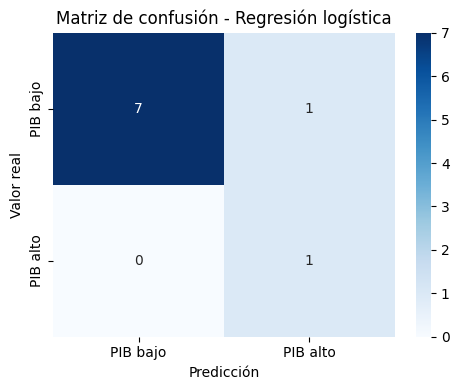

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["PIB bajo", "PIB alto"],
    yticklabels=["PIB bajo", "PIB alto"]
)

plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

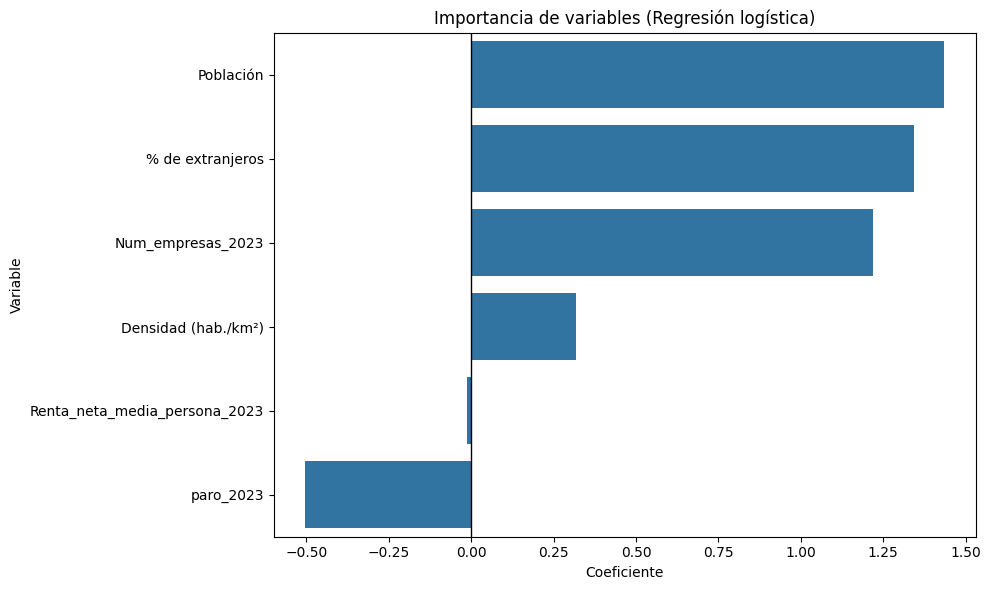

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dataframe de coeficientes ya calculado
# coef_df = pd.DataFrame({
#     "Variable": features,
#     "Coeficiente": model.coef_[0]
# }).sort_values(by="Coeficiente", ascending=False)

# # Orden descendente por importancia absoluta (más interpretativo)
# coef_df["Abs_Coef"] = coef_df["Coeficiente"].abs()
# coef_df = coef_df.sort_values("Abs_Coef", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x="Coeficiente",
    y="Variable"
)

plt.title("Importancia de variables (Regresión logística)")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

El modelo de regresión logística obtuvo una accuracy del 89%, siendo capaz de identificar correctamente todas las provincias pertenecientes al grupo de alto PIB (recall = 1.00). No obstante, el modelo genera algunos falsos positivos, lo que reduce la precisión de la clase minoritaria. Las variables con mayor peso fueron la población, el porcentaje de extranjeros y el número de empresas, indicando que las provincias más pobladas, internacionalizadas y con mayor tejido empresarial presentan una mayor probabilidad de pertenecer al grupo económicamente más fuerte. Por otro lado, la tasa de paro mostró una relación negativa con el nivel económico provincial.

## 3.2 Modelo No supervisado

In [18]:
df.columns

Index(['Provincia_x', 'Comunidad autónoma', 'Capital', 'Ciudad más poblada*',
       'Código postal', 'Código Ministerio del Interior', 'Superficie (km²)',
       'Población', 'Densidad (hab./km²)', 'Presupuesto (€)',
       ...
       'Num_empresas_2023', 'Tasa_actividad_media_2016_2023',
       'Tasa_empleo_media_2016_2023', 'Tasa_paro_media_2016_2023',
       'Renta_neta_media_persona_2016_2023',
       'Renta_neta_media_hogar_2016_2023', 'Num_empresas_media_2016_2023',
       'Residentes_España_media_2016_2023',
       'Residentes_Extranjero_media_2016_2023', 'PIB_alto'],
      dtype='object', length=101)

In [19]:
features = [
    "PIB_2023",
    "paro_2023",
    "empleo_2023",
    "Num_empresas_2023",
    "Población",
    "Densidad (hab./km²)",
    "Renta_neta_media_hogar_2023",
    "Renta_neta_media_persona_2023",
    "Residentes_Extranjero_2023",
    "Residentes_España_2023"
]

df_cluster = df[features].dropna()

K óptimo: 9


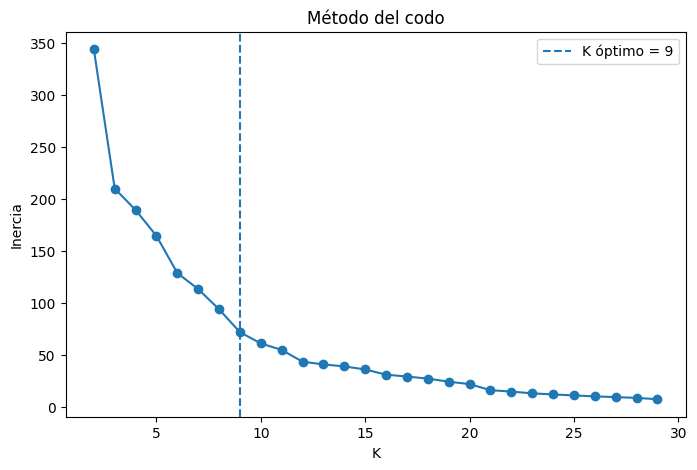

In [20]:
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
K = range(2, 30)

inertia = []

for k in range(2, 30):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

kneedle = KneeLocator(
    K,
    inertia,
    curve="convex",
    direction="decreasing"
)

k_optimo = kneedle.elbow

print("K óptimo:", k_optimo)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.axvline(k_optimo, linestyle="--", label=f"K óptimo = {k_optimo}")
plt.title("Método del codo")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.legend()
plt.show()

Elección del número de clusters
Después de comparar distintos valores de K, hemos decidido utilizar K = 9 como número final de clusters.

Esta elección se basa principalmente en dos criterios. Por un lado, el método del codo nos indicaba que a partir de K = 9 la reducción de la inercia empieza a ser menos pronunciada, por lo que añadir más clusters ya no mejora tanto el modelo. Por otro lado, al calcular el coeficiente de Silhouette, K = 9 es el valor que obtiene la puntuación más alta entre las opciones probadas.

Esto significa que, con 9 clusters, las provincias quedan agrupadas de forma relativamente coherente dentro de cada grupo y, al mismo tiempo, suficientemente diferenciadas respecto al resto de clusters.

Aunque otros valores como K = 6 también podrían ser válidos si se buscara una clasificación más simple, hemos elegido K = 9 porque ofrece un mejor equilibrio entre precisión del agrupamiento e interpretación de los resultados.

In [21]:
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_cluster["Cluster"] = clusters
df_cluster["Provincias"] = df["Provincias"]

dct_cluster = {}

for cluster in df_cluster["Cluster"].unique():
    
    dct_cluster[int(cluster)] = df_cluster.loc[df_cluster["Cluster"] == cluster, 'Provincias'].to_list()

dct_cluster

{4: ['Albacete',
  'Burgos',
  'Cuenca',
  'Cáceres',
  'Guadalajara',
  'Lleida',
  'Lugo',
  'Murcia',
  'Ourense',
  'Palencia',
  'Pontevedra',
  'Salamanca',
  'Segovia',
  'Soria',
  'Teruel',
  'Toledo',
  'Ávila'],
 0: ['Almería',
  'Badajoz',
  'Ciudad Real',
  'Cádiz',
  'Córdoba',
  'Granada',
  'Huelva',
  'Jaén',
  'Santa Cruz de Tenerife',
  'Sevilla',
  'Tarragona',
  'Zamora'],
 5: ['Araba/Álava', 'Bizkaia', 'Gipuzkoa'],
 1: ['Asturias', 'Cantabria', 'Girona', 'Málaga', 'Navarra'],
 2: ['Barcelona', 'Madrid'],
 3: ['Huesca', 'León', 'Valladolid', 'Zaragoza']}

<Axes: xlabel='PC1', ylabel='PC2'>

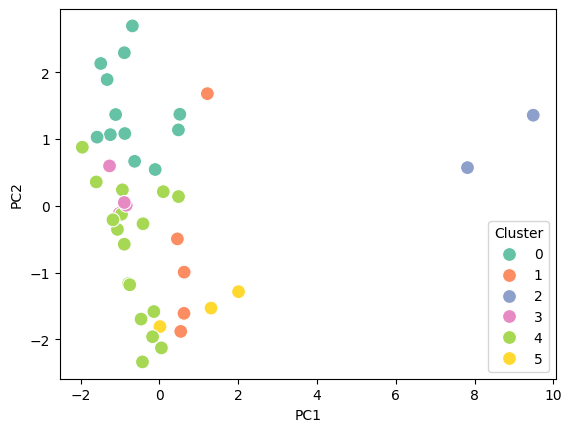

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df_plot = pd.DataFrame(components, columns=["PC1", "PC2"])
df_plot["Cluster"] = clusters
df_plot["Provincia"] = df["Provincia"]

sns.scatterplot(
    data=df_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=100
)

**Cluster 0:**
(Almería, Badajoz, Ciudad Real, Cádiz, Córdoba, Granada, Huelva, Jaén, Santa Cruz de Tenerife, Sevilla, Tarragona y Zamora)

Cluster formado principalmente por provincias del sur peninsular y territorios con una estructura económica menos diversificada. Se caracteriza por presentar tasas de paro relativamente elevadas, menor renta media y una mayor dependencia de sectores como agricultura, servicios y turismo. Tarragona aparece como un caso particular debido a su componente industrial y portuario, aunque comparte ciertas métricas socioeconómicas con este grupo.

**Cluster 1:**
(Asturias, Cantabria, Girona, Málaga y Navarra)

Cluster compuesto por provincias con un nivel económico medio-alto y una combinación de actividad turística y tejido empresarial consolidado. Navarra destaca por su fortaleza industrial y renta elevada, mientras que Girona y Málaga presentan un fuerte peso del turismo nacional e internacional. Asturias y Cantabria comparten indicadores laborales y económicos relativamente estables.

**Cluster 2:**
(Barcelona y Madrid)

Cluster formado por las dos principales áreas metropolitanas y económicas de España. Ambas provincias concentran el mayor volumen de PIB, empresas, población y actividad económica del país. También presentan alta densidad poblacional, gran diversificación sectorial y fuerte capacidad de atracción de inversión y empleo cualificado.

**Cluster 3:**
(Huesca, León, Valladolid y Zaragoza)

Cluster compuesto por provincias intermedias con cierta especialización logística, industrial y administrativa. Zaragoza y Valladolid actúan como polos regionales de actividad económica e infraestructuras, mientras que León y Huesca presentan características demográficas y económicas similares en términos de densidad y desarrollo medio.

**Cluster 4:**
(Albacete, Burgos, Cuenca, Cáceres, Guadalajara, Lleida, Lugo, Murcia, Ourense, Palencia, Pontevedra, Salamanca, Segovia, Soria, Teruel, Toledo y Ávila)

Cluster formado principalmente por provincias del interior peninsular y territorios con menor densidad poblacional. Presentan niveles intermedios de actividad económica, menor concentración empresarial y menor peso de grandes áreas metropolitanas. Aun así, algunas provincias como Murcia o Pontevedra muestran un comportamiento parcialmente diferenciado debido a su mayor actividad económica o demográfica.

**Cluster 5:**
(Araba/Álava, Bizkaia y Gipuzkoa)

Cluster correspondiente al eje industrial y económico del País Vasco. Se caracteriza por una elevada renta media, fuerte tejido industrial y empresarial, bajos niveles de desempleo y una estructura económica altamente desarrollada. Es uno de los clusters más homogéneos y diferenciados del análisis


## 3.3 contraste de hipótesis

Comparar si las provincias "Ricas" tienen más empresas que las no ricas

H0: No hay relación entre PIB y número de empresas
H1: Sí hay relación

In [23]:
from scipy import stats

# Separar grupos
group_high = df[df["PIB_alto"] == 1]["Num_empresas_2023"].dropna()
group_low = df[df["PIB_alto"] == 0]["Num_empresas_2023"].dropna()

# Test de normalidad (Shapiro)
shapiro_high = stats.shapiro(group_high)
shapiro_low = stats.shapiro(group_low)

print("Shapiro high:", shapiro_high)
print("Shapiro low:", shapiro_low)

# Si no son normales → Mann-Whitney (recomendado)
stat, p_value = stats.mannwhitneyu(group_high, group_low, alternative="two-sided")

print("\nMann-Whitney U test")
print("stat:", stat)
print("p-value:", p_value)

Shapiro high: ShapiroResult(statistic=np.float64(0.7399853686667628), pvalue=np.float64(0.009959987503767634))
Shapiro low: ShapiroResult(statistic=np.float64(0.934778096722201), pvalue=np.float64(0.028442000070053215))

Mann-Whitney U test
stat: 261.0
p-value: 8.373803041982283e-07


Para ver si el p-value es un valor real y no una ilusión estadistica usaremos d cohen para calcular la distancia maxima entre las dos distribuciones y ver realmente si existe una diferencia o no. 

In [24]:
import numpy as np

group_high = df[df["PIB_alto"] == 1]["Num_empresas_2023"].dropna()
group_low = df[df["PIB_alto"] == 0]["Num_empresas_2023"].dropna()

mean_high = group_high.mean()
mean_low = group_low.mean()

std_high = group_high.std()
std_low = group_low.std()

n1 = len(group_high)
n2 = len(group_low)

# pooled std
pooled_std = np.sqrt(
    ((n1 - 1)*std_high**2 + (n2 - 1)*std_low**2) / (n1 + n2 - 2)
)

cohen_d = (mean_high - mean_low) / pooled_std

print("Cohen's d:", cohen_d)

Cohen's d: 2.3791807608918365


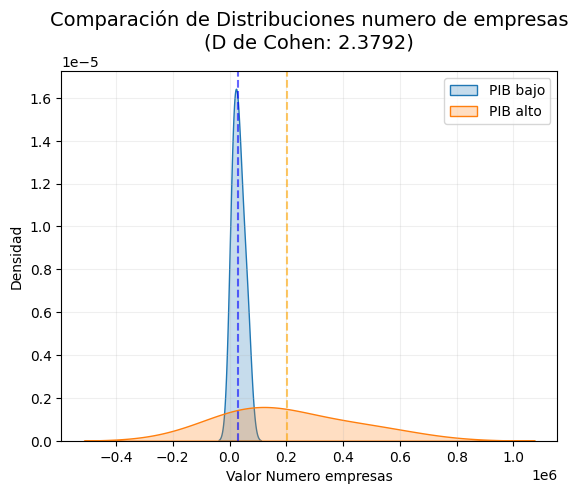

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtramos los datos
data_low_pib = df.loc[df["PIB_alto"] == 0, 'Num_empresas_2023']
data_high_pib = df.loc[df["PIB_alto"] == 1, 'Num_empresas_2023']

# Creamos el gráfico de densidad
sns.kdeplot(data_low_pib, label='PIB bajo', fill=True, bw_adjust=1.5)
sns.kdeplot(data_high_pib, label='PIB alto', fill=True, bw_adjust=1.5)

# Añadimos las líneas de las medias para marcar la "distancia"
plt.axvline(data_low_pib.mean(), color='blue', linestyle='--', alpha=0.6)
plt.axvline(data_high_pib.mean(), color='orange', linestyle='--', alpha=0.6)

plt.title(f"Comparación de Distribuciones numero de empresas\n(D de Cohen: {cohen_d:.4f})", fontsize=14)
plt.xlabel("Valor Numero empresas")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.2)

# Guardamos el gráfico asegurando que las etiquetas no se corten
plt.savefig('comparacion_distribuciones.png', bbox_inches='tight')

El análisis de contraste de hipótesis entre provincias con PIB alto y PIB bajo (definido como el 20% superior del PIB en 2023) muestra diferencias estadísticamente significativas en el número de empresas.

El test no paramétrico de Mann-Whitney U indica un p-value muy inferior a 0.05, por lo que se rechaza la hipótesis nula de igualdad de distribuciones. Esto sugiere que el tejido empresarial difiere de forma significativa entre ambos grupos de provincias.

El análisis de tamaño del efecto mediante el estadístico d de Cohen permite evaluar la magnitud de esta diferencia, observándose un efecto relevante entre ambos grupos. Esto indica que no solo existen diferencias estadísticamente significativas, sino también diferencias con importancia práctica.Un valor de d = 2.38 se sitúa muy por encima del umbral considerado como efecto grande (0.8), lo que indica una separación muy marcada entre ambos grupos. En términos prácticos, esto significa que las provincias con PIB alto tienen un tejido empresarial sustancialmente mayor que las provincias con PIB bajo, con muy poco solapamiento entre distribuciones.

La visualización mediante KDE plot muestra que las provincias con PIB bajo concentran la mayor parte de su distribución en valores reducidos de número de empresas, mientras que las provincias con PIB alto presentan una distribución desplazada hacia valores superiores y con mayor dispersión. En términos generales, el grupo de alto PIB presenta una media significativamente mayor de empresas, lo que refuerza la relación positiva entre actividad empresarial y nivel de riqueza provincial.

En conjunto, los resultados apoyan la existencia de una relación estructural entre el desarrollo económico provincial y la densidad del tejido empresarial, evidenciando que las provincias económicamente más fuertes tienden a concentrar un mayor número de empresas y mayor heterogeneidad en su estructura productiva.